In [1]:
!pip install -q xgboost kagglehub joblib seaborn

In [2]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import kagglehub

path = kagglehub.dataset_download(
    "behrad3d/nasa-cmaps"
)

print("Dataset downloaded to:")
print(path)

print("\nFiles:")
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

Using Colab cache for faster access to the 'nasa-cmaps' dataset.
Dataset downloaded to:
/kaggle/input/nasa-cmaps

Files:
/kaggle/input/nasa-cmaps/CMaps/RUL_FD002.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD003.txt
/kaggle/input/nasa-cmaps/CMaps/Damage Propagation Modeling.pdf
/kaggle/input/nasa-cmaps/CMaps/readme.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD003.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD004.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD004.txt
/kaggle/input/nasa-cmaps/CMaps/x.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD002.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD001.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD002.txt
/kaggle/input/nasa-cmaps/CMaps/RUL_FD001.txt
/kaggle/input/nasa-cmaps/CMaps/RUL_FD004.txt
/kaggle/input/nasa-cmaps/CMaps/RUL_FD003.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD001.txt


In [4]:
def find_file(filename):
    matches = []

    for root, dirs, files in os.walk(path):
        if filename in files:
            matches.append(
                os.path.join(root, filename)
            )

    if len(matches) == 0:
        raise FileNotFoundError(
            f"{filename} not found"
        )

    return matches[0]


train_path = find_file("train_FD001.txt")
test_path = find_file("test_FD001.txt")
rul_path = find_file("RUL_FD001.txt")

print("Train:", train_path)
print("Test :", test_path)
print("RUL  :", rul_path)

Train: /kaggle/input/nasa-cmaps/CMaps/train_FD001.txt
Test : /kaggle/input/nasa-cmaps/CMaps/test_FD001.txt
RUL  : /kaggle/input/nasa-cmaps/CMaps/RUL_FD001.txt


In [5]:
columns = [
    "engine_id",
    "cycle",
    "setting_1",
    "setting_2",
    "setting_3"
]

sensor_columns = [
    f"sensor_{i}"
    for i in range(1, 22)
]

columns = columns + sensor_columns

print("Number of columns:", len(columns))

print(columns)

Number of columns: 26
['engine_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [6]:
train_df = pd.read_csv(
    train_path,
    sep=r"\s+",
    header=None,
    names=columns
)

print("Training data shape:")
print(train_df.shape)

train_df.head()

Training data shape:
(20631, 26)


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [7]:
test_df = pd.read_csv(
    test_path,
    sep=r"\s+",
    header=None,
    names=columns
)

print("Test data shape:")
print(test_df.shape)

test_df.head()

Test data shape:
(13096, 26)


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [8]:
rul_df = pd.read_csv(
    rul_path,
    sep=r"\s+",
    header=None,
    names=["RUL"]
)

print("Test RUL shape:")
print(rul_df.shape)

rul_df.head()

Test RUL shape:
(100, 1)


,RUL
0,112
1,98
2,69
3,82
4,91


In [9]:
print("TRAINING DATA")
print("=" * 50)

print("Shape:", train_df.shape)

print("\nNumber of engines:")
print(train_df["engine_id"].nunique())

print("\nCycles per engine:")
print(
    train_df
    .groupby("engine_id")["cycle"]
    .max()
    .describe()
)

print("\nMissing values:")
print(train_df.isnull().sum().sum())

TRAINING DATA
Shape: (20631, 26)

Number of engines:
100

Cycles per engine:
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

Missing values:
0


In [10]:
max_cycle = (
    train_df
    .groupby("engine_id")["cycle"]
    .max()
    .reset_index()
)

max_cycle.columns = [
    "engine_id",
    "max_cycle"
]

train_df = train_df.merge(
    max_cycle,
    on="engine_id",
    how="left"
)

train_df["RUL"] = (
    train_df["max_cycle"]
    - train_df["cycle"]
)

train_df.drop(
    columns=["max_cycle"],
    inplace=True
)

train_df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


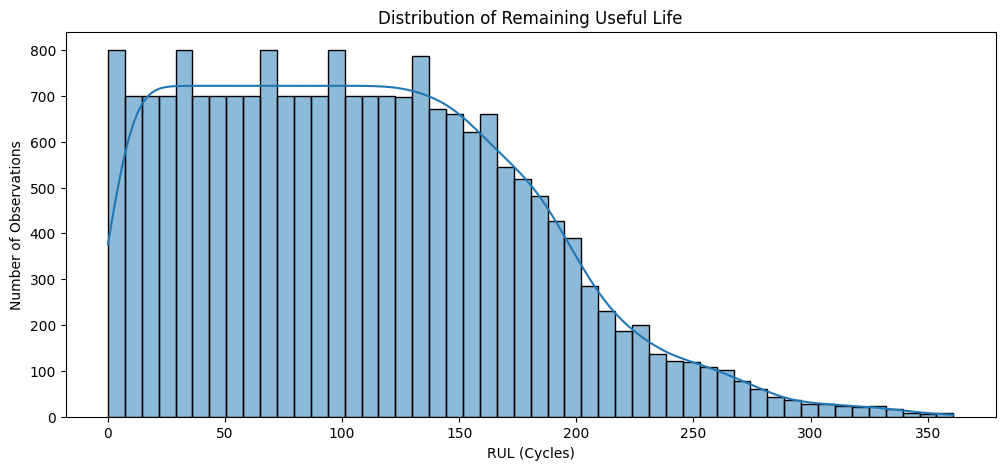

In [11]:
plt.figure(figsize=(12, 5))

sns.histplot(
    train_df["RUL"],
    bins=50,
    kde=True
)

plt.title("Distribution of Remaining Useful Life")
plt.xlabel("RUL (Cycles)")
plt.ylabel("Number of Observations")

plt.show()

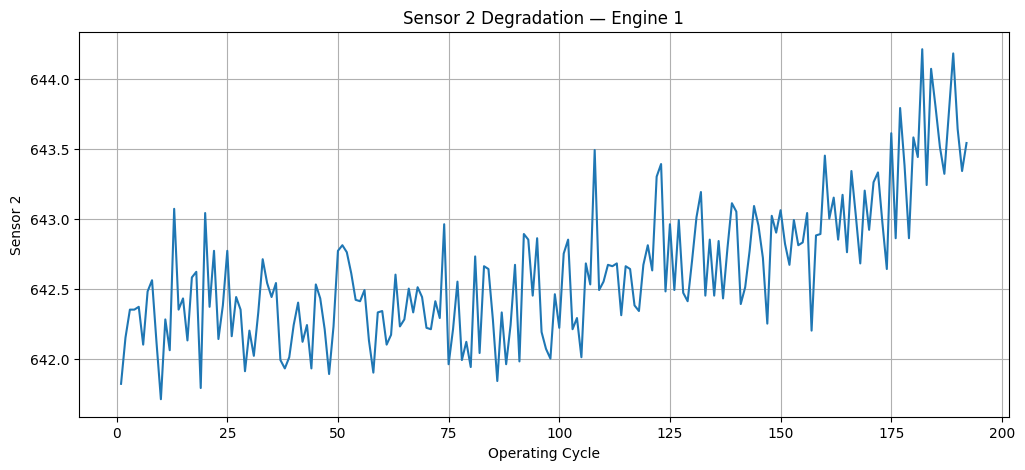

In [12]:
engine_id = 1

engine_data = train_df[
    train_df["engine_id"] == engine_id
]

plt.figure(figsize=(12, 5))

plt.plot(
    engine_data["cycle"],
    engine_data["sensor_2"]
)

plt.xlabel("Operating Cycle")
plt.ylabel("Sensor 2")

plt.title(
    f"Sensor 2 Degradation — Engine {engine_id}"
)

plt.grid(True)

plt.show()

In [13]:
useless_sensors = [
    "sensor_1",
    "sensor_5",
    "sensor_6",
    "sensor_10",
    "sensor_16",
    "sensor_18",
    "sensor_19"
]

train_df = train_df.drop(
    columns=useless_sensors
)

test_df = test_df.drop(
    columns=useless_sensors
)

print("Remaining columns:")
print(train_df.columns.tolist())

Remaining columns:
['engine_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'RUL']


In [14]:
sensor_cols = [
    col for col in train_df.columns
    if col.startswith("sensor_")
]

print("Sensors used:")
print(sensor_cols)

Sensors used:
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [15]:
def create_features(df):

    df = df.copy()

    sensor_cols = [
        col for col in df.columns
        if col.startswith("sensor_")
    ]

    df = df.sort_values(
        ["engine_id", "cycle"]
    )

    for sensor in sensor_cols:

        # Rolling mean
        df[f"{sensor}_mean_5"] = (
            df
            .groupby("engine_id")[sensor]
            .transform(
                lambda x:
                x.rolling(
                    window=5,
                    min_periods=1
                ).mean()
            )
        )

        # Rolling standard deviation
        df[f"{sensor}_std_5"] = (
            df
            .groupby("engine_id")[sensor]
            .transform(
                lambda x:
                x.rolling(
                    window=5,
                    min_periods=1
                ).std()
            )
        )

    df = df.fillna(0)

    return df


train_features = create_features(
    train_df
)

test_features = create_features(
    test_df
)

print(
    "Training feature shape:",
    train_features.shape
)

print(
    "Testing feature shape:",
    test_features.shape
)

Training feature shape: (20631, 48)
Testing feature shape: (13096, 47)


In [43]:
test_features.to_csv(
    "test_features.csv",
    index=False
)

print("test_features.csv saved!")

test_features.csv saved!


In [44]:
from google.colab import files

files.download("test_features.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
joblib.dump(
    list(X.columns),
    "feature_names.pkl"
)

files.download("feature_names.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
drop_columns = [
    "RUL",
    "engine_id"
]

X = train_features.drop(
    columns=drop_columns
)

y = train_features["RUL"]

groups = train_features["engine_id"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20631, 46)
y shape: (20631,)


In [17]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, val_idx = next(
    gss.split(
        X,
        y,
        groups=groups
    )
)

X_train = X.iloc[train_idx]
X_val = X.iloc[val_idx]

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]

print("Training rows:", len(X_train))
print("Validation rows:", len(X_val))

print(
    "Training engines:",
    groups.iloc[train_idx].nunique()
)

print(
    "Validation engines:",
    groups.iloc[val_idx].nunique()
)

Training rows: 16561
Validation rows: 4070
Training engines: 80
Validation engines: 20


In [18]:
model = XGBRegressor(

    n_estimators=1000,

    max_depth=6,

    learning_rate=0.03,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="reg:squarederror",

    eval_metric="mae",

    random_state=42,

    n_jobs=-1
)

print("Training XGBoost...")

model.fit(
    X_train,
    y_train,
    eval_set=[
        (X_train, y_train),
        (X_val, y_val)
    ],
    verbose=False
)

print("Training completed!")

Training XGBoost...
Training completed!


In [20]:
y_val_pred = model.predict(
    X_val
)

y_val_pred = np.maximum(
    y_val_pred,
    0
)

print("Predictions generated!")

Predictions generated!


In [21]:
y_val_pred = model.predict(
    X_val
)

y_val_pred = np.maximum(
    y_val_pred,
    0
)

print("Predictions generated!")

Predictions generated!


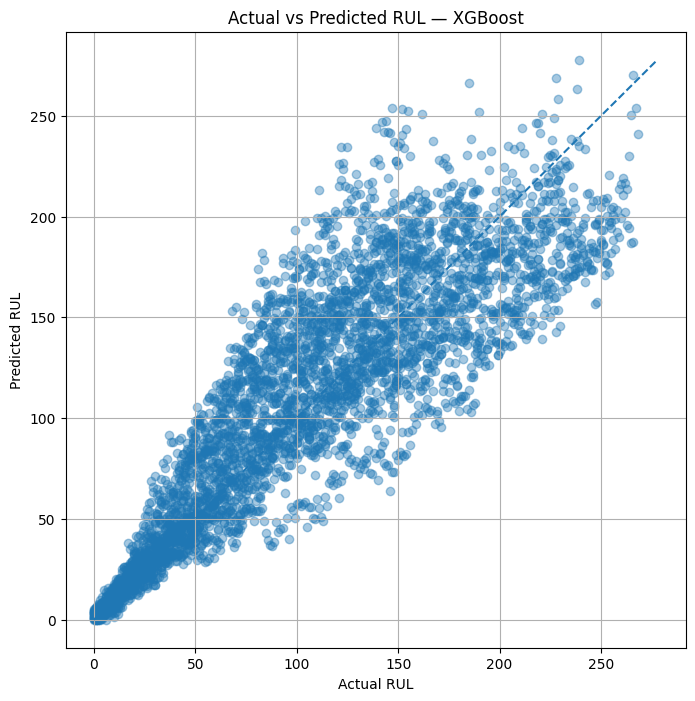

In [22]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_val,
    y_val_pred,
    alpha=0.4
)

min_value = min(
    y_val.min(),
    y_val_pred.min()
)

max_value = max(
    y_val.max(),
    y_val_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")

plt.title(
    "Actual vs Predicted RUL — XGBoost"
)

plt.grid(True)

plt.show()

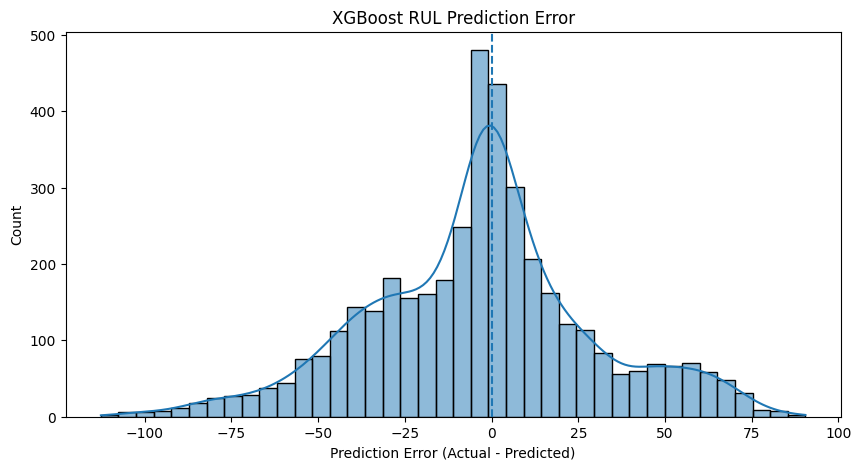

In [23]:
errors = y_val - y_val_pred

plt.figure(figsize=(10, 5))

sns.histplot(
    errors,
    bins=40,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Prediction Error (Actual - Predicted)"
)

plt.ylabel("Count")

plt.title(
    "XGBoost RUL Prediction Error"
)

plt.show()

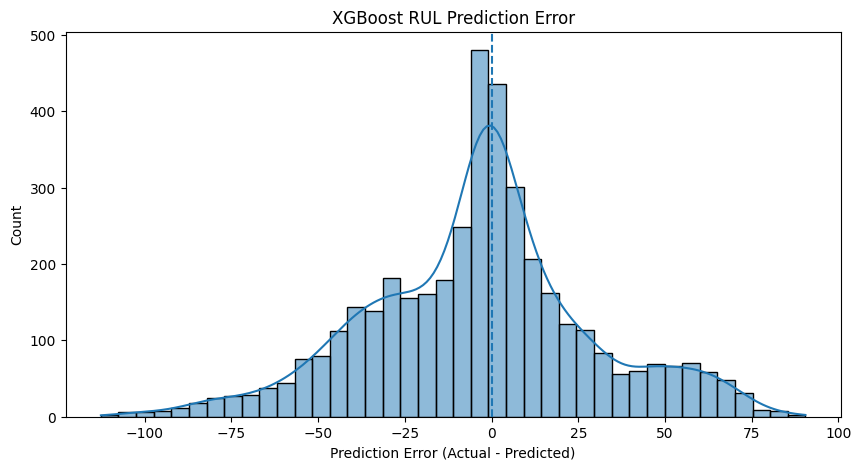

In [24]:
errors = y_val - y_val_pred

plt.figure(figsize=(10, 5))

sns.histplot(
    errors,
    bins=40,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Prediction Error (Actual - Predicted)"
)

plt.ylabel("Count")

plt.title(
    "XGBoost RUL Prediction Error"
)

plt.show()

In [26]:
test_final = (
    test_features
    .sort_values(
        ["engine_id", "cycle"]
    )
    .groupby(
        "engine_id"
    )
    .tail(1)
    .copy()
)

print(
    "Number of test engines:",
    len(test_final)
)

test_final.head()

Number of test engines: 100


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,...,sensor_14_mean_5,sensor_14_std_5,sensor_15_mean_5,sensor_15_std_5,sensor_17_mean_5,sensor_17_std_5,sensor_20_mean_5,sensor_20_std_5,sensor_21_mean_5,sensor_21_std_5
30,1,31,-0.0006,0.0004,100.0,642.58,1581.22,1398.91,554.42,2388.08,...,8132.032,3.302941,8.42620,0.021174,392.0,0.707107,38.924,0.124016,23.37350,0.025037
79,2,49,0.0018,-0.0001,100.0,642.55,1586.59,1410.83,553.52,2388.10,...,8127.672,1.370062,8.44226,0.011429,392.2,1.095445,38.902,0.069785,23.27434,0.027820
205,3,126,-0.0016,0.0004,100.0,642.88,1589.75,1418.89,552.59,2388.16,...,8129.666,2.979090,8.45868,0.030924,394.2,0.836660,38.686,0.143631,23.24412,0.018966
311,4,106,0.0012,0.0004,100.0,642.78,1594.53,1406.88,552.64,2388.13,...,8134.328,0.622953,8.45182,0.021249,393.6,1.341641,38.758,0.126372,23.25156,0.021106
409,5,98,-0.0013,-0.0004,100.0,642.27,1589.94,1419.36,553.29,2388.10,...,8128.798,1.923609,8.43662,0.009627,393.4,0.547723,38.810,0.091924,23.29114,0.101100


In [27]:
X_test_final = test_final.drop(
    columns=["engine_id"]
)

X_test_final = X_test_final[
    X.columns
]

print(
    "Test feature shape:",
    X_test_final.shape
)

Test feature shape: (100, 46)


In [28]:
test_predictions = model.predict(
    X_test_final
)

test_predictions = np.maximum(
    test_predictions,
    0
)

test_predictions[:10]

array([203.501   , 148.65681 ,  53.032295,  74.58191 , 120.03519 ,
       104.89954 , 131.48083 ,  79.31377 , 152.54771 , 125.8284  ],
      dtype=float32)

In [29]:
true_rul = rul_df["RUL"].values

comparison = pd.DataFrame({

    "Engine_ID":
        test_final["engine_id"].values,

    "Actual_RUL":
        true_rul,

    "Predicted_RUL":
        test_predictions

})

comparison["Error"] = (
    comparison["Actual_RUL"]
    - comparison["Predicted_RUL"]
)

comparison["Absolute_Error"] = (
    comparison["Error"]
    .abs()
)

comparison.head(10)

,Engine_ID,Actual_RUL,Predicted_RUL,Error,Absolute_Error
0,1,112,203.501007,-91.501007,91.501007
1,2,98,148.656815,-50.656815,50.656815
2,3,69,53.032295,15.967705,15.967705
3,4,82,74.581909,7.418091,7.418091
4,5,91,120.035187,-29.035187,29.035187
5,6,93,104.899544,-11.899544,11.899544
6,7,91,131.480835,-40.480835,40.480835
7,8,95,79.313766,15.686234,15.686234
8,9,111,152.547714,-41.547714,41.547714
9,10,96,125.828400,-29.828400,29.828400


In [30]:
test_mae = mean_absolute_error(
    comparison["Actual_RUL"],
    comparison["Predicted_RUL"]
)

test_rmse = np.sqrt(
    mean_squared_error(
        comparison["Actual_RUL"],
        comparison["Predicted_RUL"]
    )
)

test_r2 = r2_score(
    comparison["Actual_RUL"],
    comparison["Predicted_RUL"]
)

print("=" * 50)
print("FINAL TEST PERFORMANCE")
print("=" * 50)

print(
    f"MAE  : {test_mae:.2f} cycles"
)

print(
    f"RMSE : {test_rmse:.2f} cycles"
)

print(
    f"R²   : {test_r2:.4f}"
)

FINAL TEST PERFORMANCE
MAE  : 23.21 cycles
RMSE : 31.81 cycles
R²   : 0.4141


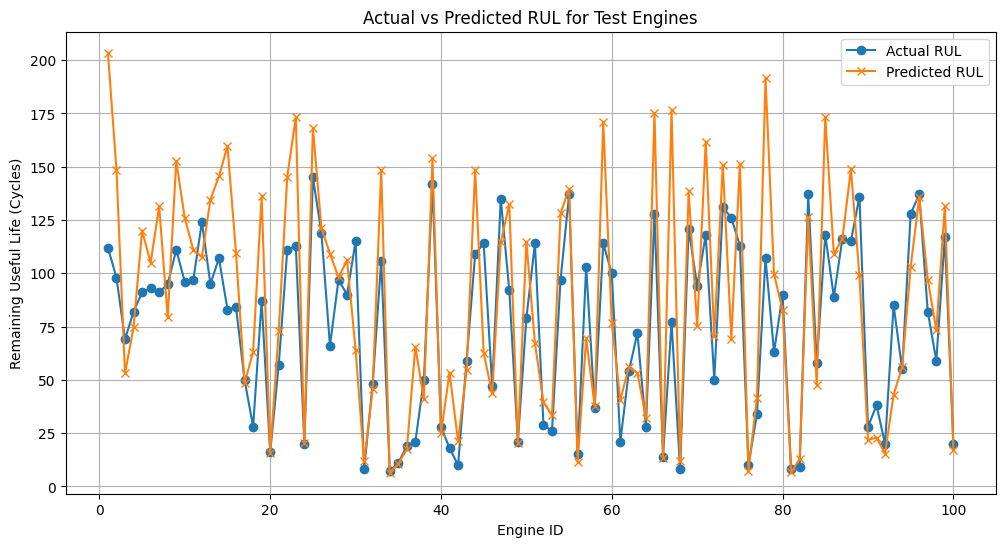

In [31]:
plt.figure(figsize=(12, 6))

plt.plot(
    comparison["Engine_ID"],
    comparison["Actual_RUL"],
    marker="o",
    label="Actual RUL"
)

plt.plot(
    comparison["Engine_ID"],
    comparison["Predicted_RUL"],
    marker="x",
    label="Predicted RUL"
)

plt.xlabel("Engine ID")

plt.ylabel("Remaining Useful Life (Cycles)")

plt.title(
    "Actual vs Predicted RUL for Test Engines"
)

plt.legend()

plt.grid(True)

plt.show()

In [32]:
worst_predictions = (
    comparison
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
    .head(10)
)

worst_predictions

,Engine_ID,Actual_RUL,Predicted_RUL,Error,Absolute_Error
66,67,77,176.520615,-99.520615,99.520615
0,1,112,203.501007,-91.501007,91.501007
77,78,107,191.511551,-84.511551,84.511551
14,15,83,159.761993,-76.761993,76.761993
22,23,113,173.328491,-60.328491,60.328491
58,59,114,171.058136,-57.058136,57.058136
73,74,126,69.372932,56.627068,56.627068
84,85,118,173.409882,-55.409882,55.409882
44,45,114,62.565357,51.434643,51.434643
29,30,115,64.202293,50.797707,50.797707


In [33]:
def maintenance_status(rul):

    if rul > 50:
        return "🟢 HEALTHY"

    elif rul > 20:
        return "🟡 WARNING"

    else:
        return "🔴 CRITICAL"


comparison["Status"] = (
    comparison["Predicted_RUL"]
    .apply(maintenance_status)
)

comparison.head(20)

,Engine_ID,Actual_RUL,Predicted_RUL,Error,Absolute_Error,Status
0,1,112,203.501007,-91.501007,91.501007,🟢 HEALTHY
1,2,98,148.656815,-50.656815,50.656815,🟢 HEALTHY
2,3,69,53.032295,15.967705,15.967705,🟢 HEALTHY
3,4,82,74.581909,7.418091,7.418091,🟢 HEALTHY
4,5,91,120.035187,-29.035187,29.035187,🟢 HEALTHY
5,6,93,104.899544,-11.899544,11.899544,🟢 HEALTHY
6,7,91,131.480835,-40.480835,40.480835,🟢 HEALTHY
7,8,95,79.313766,15.686234,15.686234,🟢 HEALTHY
8,9,111,152.547714,-41.547714,41.547714,🟢 HEALTHY
9,10,96,125.828400,-29.828400,29.828400,🟢 HEALTHY


In [34]:
def maintenance_status(rul):

    if rul > 50:
        return "🟢 HEALTHY"

    elif rul > 20:
        return "🟡 WARNING"

    else:
        return "🔴 CRITICAL"


comparison["Status"] = (
    comparison["Predicted_RUL"]
    .apply(maintenance_status)
)

comparison.head(20)

,Engine_ID,Actual_RUL,Predicted_RUL,Error,Absolute_Error,Status
0,1,112,203.501007,-91.501007,91.501007,🟢 HEALTHY
1,2,98,148.656815,-50.656815,50.656815,🟢 HEALTHY
2,3,69,53.032295,15.967705,15.967705,🟢 HEALTHY
3,4,82,74.581909,7.418091,7.418091,🟢 HEALTHY
4,5,91,120.035187,-29.035187,29.035187,🟢 HEALTHY
5,6,93,104.899544,-11.899544,11.899544,🟢 HEALTHY
6,7,91,131.480835,-40.480835,40.480835,🟢 HEALTHY
7,8,95,79.313766,15.686234,15.686234,🟢 HEALTHY
8,9,111,152.547714,-41.547714,41.547714,🟢 HEALTHY
9,10,96,125.828400,-29.828400,29.828400,🟢 HEALTHY


In [35]:
critical_engine = (
    comparison
    .sort_values(
        "Predicted_RUL"
    )
    .iloc[0]
)

print(
    "Engine requiring earliest maintenance:"
)

print(
    f"Engine ID: "
    f"{int(critical_engine['Engine_ID'])}"
)

print(
    f"Predicted RUL: "
    f"{critical_engine['Predicted_RUL']:.2f} cycles"
)

print(
    f"Status: "
    f"{critical_engine['Status']}"
)

Engine requiring earliest maintenance:
Engine ID: 34
Predicted RUL: 6.43 cycles
Status: 🔴 CRITICAL


In [36]:
joblib.dump(
    model,
    "xgboost_turbofan_rul_model.pkl"
)

print(
    "Model saved as:"
)

print(
    "xgboost_turbofan_rul_model.pkl"
)

Model saved as:
xgboost_turbofan_rul_model.pkl


In [37]:
comparison.to_csv(
    "turbofan_rul_predictions.csv",
    index=False
)

print(
    "Predictions saved!"
)

Predictions saved!


In [38]:
from google.colab import files

files.download(
    "xgboost_turbofan_rul_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
!pip install -q shap

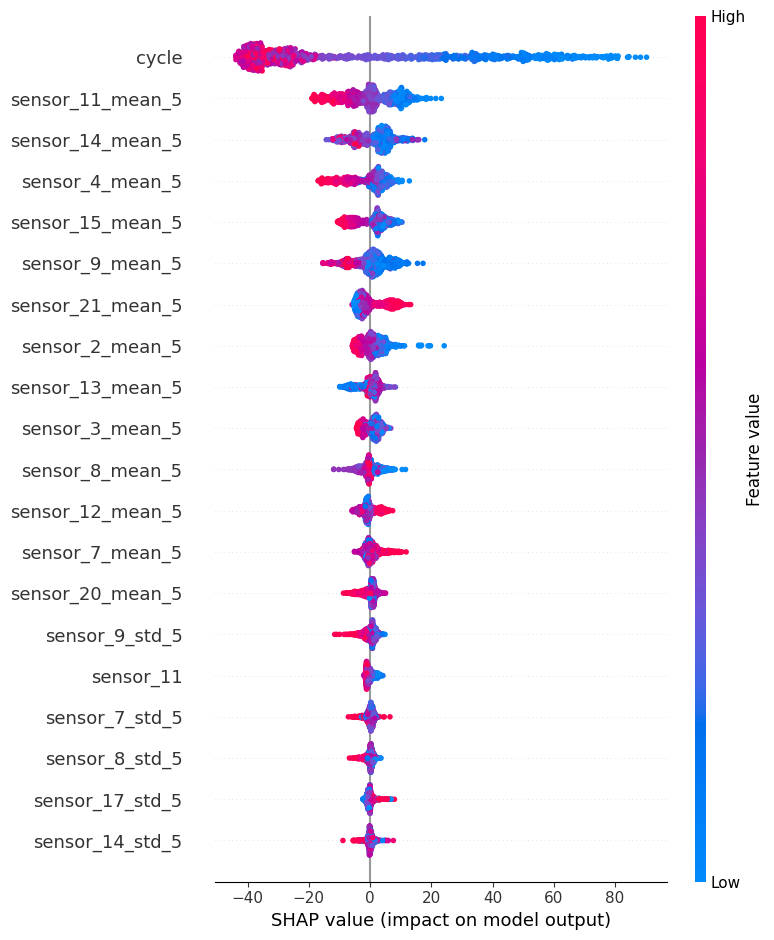

In [40]:
import shap

explainer = shap.TreeExplainer(model)

sample_data = X_val.sample(
    min(1000, len(X_val)),
    random_state=42
)

shap_values = explainer(
    sample_data
)

shap.summary_plot(
    shap_values,
    sample_data,
    max_display=20
)

In [41]:
shap_importance = pd.DataFrame({
    "Feature": sample_data.columns,
    "Importance": np.abs(
        shap_values.values
    ).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

shap_importance.head(20)

,Feature,Importance
0,cycle,33.871803
30,sensor_11_mean_5,6.917742
36,sensor_14_mean_5,4.933214
22,sensor_4_mean_5,4.884981
38,sensor_15_mean_5,4.452165
28,sensor_9_mean_5,3.975796
44,sensor_21_mean_5,3.728126
18,sensor_2_mean_5,2.879295
34,sensor_13_mean_5,2.259462
20,sensor_3_mean_5,2.171456


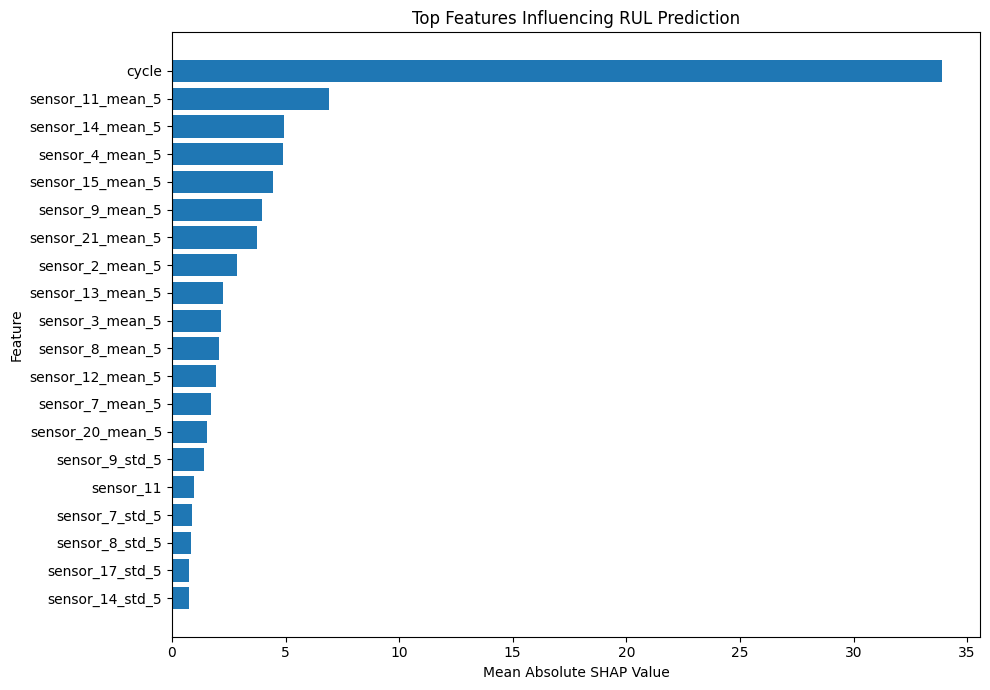

In [42]:
plt.figure(figsize=(10, 7))

top_shap = (
    shap_importance
    .head(20)
    .sort_values("Importance")
)

plt.barh(
    top_shap["Feature"],
    top_shap["Importance"]
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel("Feature")

plt.title(
    "Top Features Influencing RUL Prediction"
)

plt.tight_layout()

plt.show()

In [46]:
from google.colab import files

files.download("turbofan_rul_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>